In [1]:
import os
import math
import json
import warnings
import itertools
from datetime import datetime
warnings.filterwarnings("ignore")

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [3]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [5]:
sdf = ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()
sdf.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in sdf.index])

sdf

,datetime,open,high,low,close,volume,trade
timestamp,,,,,,,
1705395660,2024-01-16 12:31:00,43032.7,43040.0,42985.6,43003.7,201.772,3323
1705395720,2024-01-16 12:32:00,43004.5,43016.0,42960.0,42967.3,534.556,4093
1705395780,2024-01-16 12:33:00,42967.3,42976.5,42954.2,42957.8,117.148,1847
1705395840,2024-01-16 12:34:00,42957.9,42965.7,42928.9,42942.2,245.105,3502
1705395900,2024-01-16 12:35:00,42942.3,42953.0,42919.0,42942.6,134.988,1928
...,...,...,...,...,...,...,...
1712177820,2024-04-04 00:27:00,65720.0,65773.0,65720.0,65772.9,91.737,1309
1712177880,2024-04-04 00:28:00,65772.9,65773.0,65720.4,65733.7,78.019,951
1712177940,2024-04-04 00:29:00,65733.7,65749.6,65724.5,65729.3,44.781,900


In [6]:
WINDOW = 11

df = sdf.copy()[-1440 * 5:]
# df = remove_price_dependency(df=df)
# df = np.round(df, 6)

df["roc"] = df.close / df.open - 1
df["aroc"] = np.abs(df.roc).rolling(window=10).mean()

df["cmax"] = df.close.rolling(window=WINDOW, center=True).max()
df["cmin"] = df.close.rolling(window=WINDOW, center=True).min()
df["isf"] = (df.close == df.cmin) | (df.close == df.cmax)
df = df.dropna()

print(df.isf.sum())
print(df.isf.sum() / len(df))

df

937
0.13039242972446424


,datetime,open,high,low,close,volume,trade,roc,aroc,cmax,cmin,isf
timestamp,,,,,,,,,,,,
1711746660,2024-03-30 00:41:00,69626.8,69626.9,69544.5,69544.5,46.075,976,-0.001182,0.000479,69626.9,69533.9,False
1711746720,2024-03-30 00:42:00,69544.5,69590.0,69537.5,69580.2,61.182,972,0.000513,0.000510,69626.9,69533.9,False
1711746780,2024-03-30 00:43:00,69580.1,69608.4,69567.4,69608.4,23.509,564,0.000407,0.000519,69626.9,69533.9,False
1711746840,2024-03-30 00:44:00,69608.4,69626.0,69608.4,69618.0,31.558,624,0.000138,0.000514,69626.9,69540.2,False
1711746900,2024-03-30 00:45:00,69618.0,69618.1,69565.2,69579.0,55.087,1026,-0.000560,0.000553,69626.9,69532.4,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1712177520,2024-04-04 00:22:00,65604.7,65682.5,65604.7,65682.5,92.722,1322,0.001186,0.000522,65772.9,65604.7,False
1712177580,2024-04-04 00:23:00,65682.5,65720.0,65680.8,65717.1,104.318,1493,0.000527,0.000541,65772.9,65604.7,False
1712177640,2024-04-04 00:24:00,65717.1,65750.7,65717.0,65723.9,91.291,1413,0.000103,0.000482,65772.9,65604.7,False


In [15]:
def find_sub_sequences(df):
    points = [(ts, df.close.loc[ts]) for ts in df.index if df.isf.loc[ts]]

    sub_sequences = [[]]
    for point in points:
        tmp_sub_sequences = []
        for sub_sequence in sub_sequences:
            tmp_sub_sequences.append(sub_sequence)
    
            # add point if satisfice confidtions
            is_valid_point = False
            if len(sub_sequence) < 2:
                is_valid_point = True
            else:
                x = np.array([item[0] for item in sub_sequence]).reshape(-1, 1)
                y = np.array([item[1] for item in sub_sequence]).reshape(-1, 1)
    
                model = LinearRegression()
                model.fit(x, y)
                
                x_prime = np.array(point[0]).reshape(-1, 1)
                y_prime = np.array(point[1]).reshape(-1, 1)
                y_hat = model.predict(x_prime)
                error = np.abs(y_prime - y_hat).item()
    
                if error < point[1] * df.close.iloc[-1] * 0.0005:
                    is_valid_point = True
                
                
            if is_valid_point:
                new_sub_sequence = sub_sequence.copy()
                new_sub_sequence.append(point)
                tmp_sub_sequences.append(new_sub_sequence)
    
        
        sub_sequences = tmp_sub_sequences

    return sub_sequences


def merge_lines(sub_sequences):
    raw_lines = []
    for sub_sequence in sub_sequences:
        if 3 < len(sub_sequence):
            x = np.array([item[0] for item in sub_sequence]).reshape(-1, 1)
            y = np.array([item[1] for item in sub_sequence]).reshape(-1, 1)
            
            model = LinearRegression()
            model.fit(x, y)

            slope = model.coef_.item()
            intercept = model.intercept_.item()
        
            raw_lines.append([slope, intercept])
    
    x = np.array(raw_lines)
    model = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(x)
    lines = model.cluster_centers_.tolist()

    return lines


def find_trend_lines(df):
    sub_sequences = find_sub_sequences(df)
    lines = merge_lines(sub_sequences)

    return lines


def find_order_price(lines, timestamp, close_pirce):
    levels = np.array([timestamp * line[0] + line[1] for line in lines])
    below_levels = levels[levels < close_pirce]
    if 0 < len(below_levels):
        return below_levels.max()

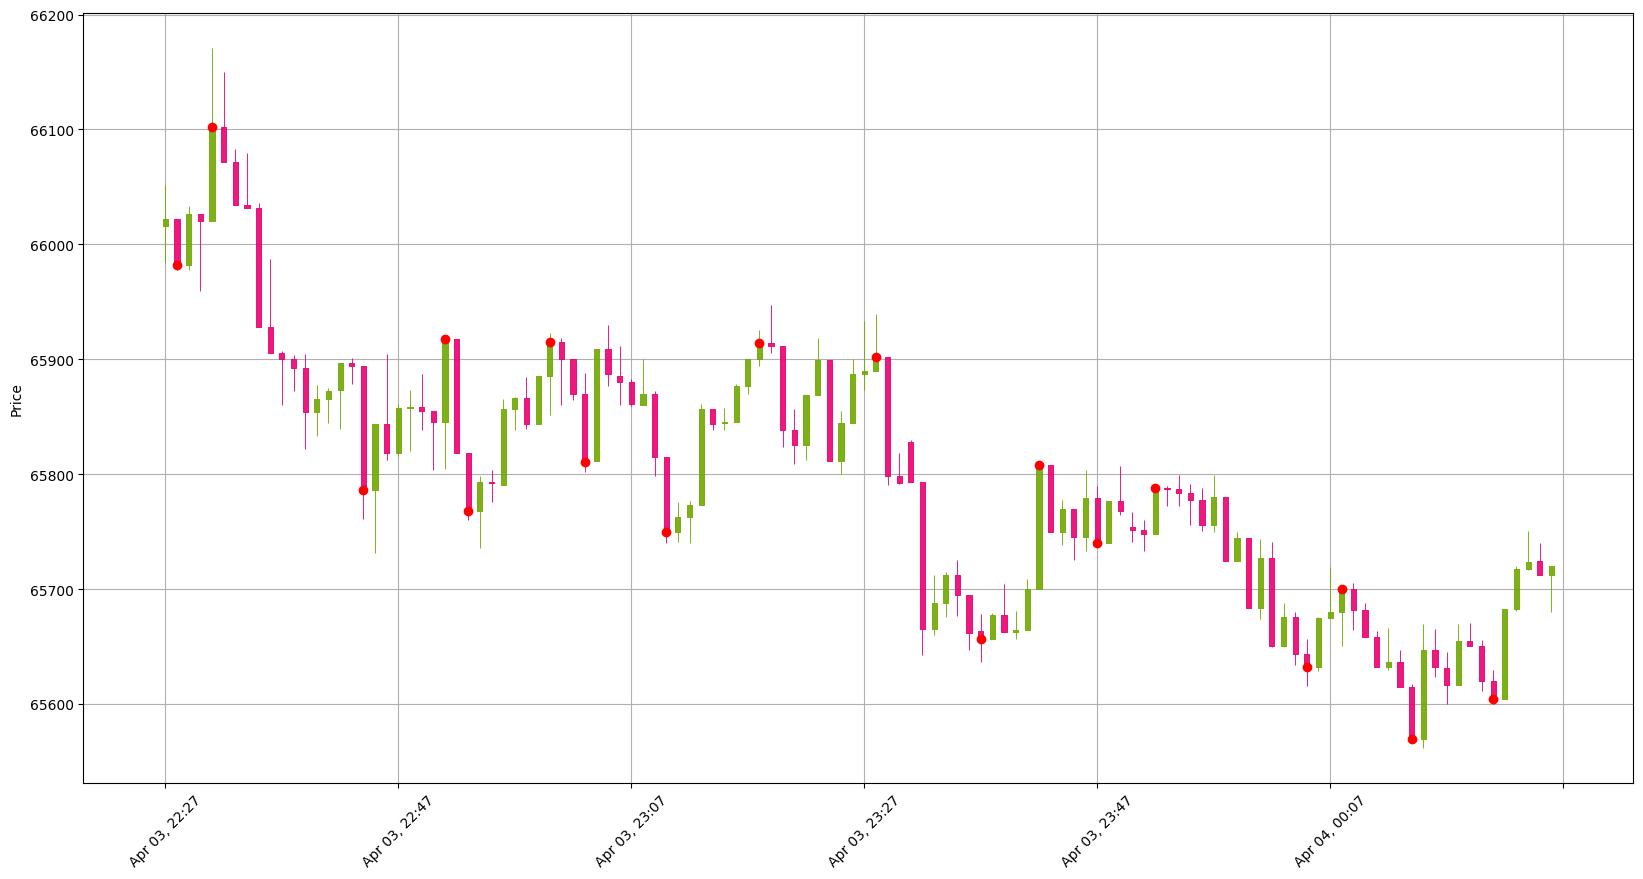

In [16]:
pdf = df[-120:]
rpdf = pdf.reset_index()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
ax.grid()

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(rpdf.close[rpdf.isf], "ro")

# lines = find_trend_lines(df=pdf)
# for slope, intercept in lines:
#     x = len(pdf) // 2
#     xy1 = (x, slope * x + intercept)
#     color = "g" if 0 < slope else "r"
#     ax.axline(xy1=xy1, slope=slope, color=color)

# timestamp = df.timestamp.iloc[-1]
# close_price = df.close.loc[timestamp]
# order_price = find_order_price(lines=lines, timestamp=timestamp, close_price=close_price)
# if order_price is not None:
#     ax.axhline(order_price)

In [ ]:
DEBUG = False
LOOKBACK = 120
TPM = 5
SLM = 100
VAR = 0.1

bars_list = []
profits_list = []
leverages_list = []

lines_index, lines = None, None
order_index, order_price = None, None
entry_index, entry_price = None, None
for index in tqdm(range(LOOKBACK, len(df))):
    if DEBUG:
        o = df.open.iloc[index]
        h = df.high.iloc[index]
        l = df.low.iloc[index]
        c = df.close.iloc[index]
        print("{} {} {} {} {}".format(df.datetime.iloc[index], o, h, l, c))
        
    if entry_index is None:
        if lines_index is None or 120 < index - lines_index:
            bdf = df.iloc[index - LOOKBACK: index]
            
            lines_index = index
            lines = find_trend_lines(df=bdf)
            
        # reset order 
        if order_index is not None and 10 < index - order_index:
            order_index = None
            order_price = None

            if DEBUG:
                print("{:<64} Reset order".format(str(df.datetime.iloc[index])))

        # set order
        if order_index is None:
            relative_index = index - lines_index + LOOKBACK
            close_price = df.close.iloc[index]
            price_level = find_order_price(lines=lines, index=relative_index, price=close_price)
            if price_level is not None:
                order_index = index
                order_price = round(price_level, 2)

                if DEBUG:
                    print("{:<64} Set new order {}".format(str(df.datetime.iloc[index]), order_price))

        # check for fill condition
        if order_index is not None and df.low.iloc[index] <= order_price <= df.high.iloc[index]:
            entry_index = index
            entry_price = order_price
            
            volatility = round(df.aroc.iloc[index], 4)
            take_profit_rate = round(volatility * TPM, 4)
            stop_loss_rate = round(volatility * SLM, 4)

            leverage = VAR // stop_loss_rate
            leverage = max(1, leverage)
            leverage = min(leverage, 100)
            
            take_profit_price = round(entry_price * (1 + take_profit_rate), 2)
            stop_loss_price = round(entry_price * (1 - stop_loss_rate), 2)

            order_price = None
            order_index = None
            
            if DEBUG:
                print("{:<64} Entry Position VOL/TPR/SLR/LVG {}/{}/{}/{} EN/TP/SL {}/{}/{}"
                      .format(str(df.datetime.iloc[index]), volatility, take_profit_rate, stop_loss_rate, leverage, entry_price, take_profit_price, stop_loss_price))
            
    if entry_index is not None:
        exit_price = None
        if df.low.iloc[index] <= stop_loss_price:
            exit_price = stop_loss_price
            fee = 0.001
        elif take_profit_price < df.high.iloc[index]:
            exit_price = take_profit_price
            fee = 0.0005
        
        if exit_price is not None:
            bars = index - entry_index
            realized_profit = round(exit_price / entry_price - 1, 4)
            profit = round((realized_profit - fee) * leverage, 4)
            
            bars_list.append(bars)
            profits_list.append(profit)
            leverages_list.append(leverage)

            entry_index = None
            entry_price = None
            
            if DEBUG:
                print("{:<64} Exit position RPNL/Profit/Bars {}/{}/{}".format(str(df.datetime.iloc[index]), realized_profit, profit, bars))
                print("=" * 64)
                print()

        if DEBUG and 10 == len(profits_list):
            break 

In [ ]:
bars = np.array(bars_list)
profits = np.array(profits_list)
leverages = np.array(leverages_list)

days = len(df) * TimeFrame.MIN1 // TimeFrame.DAY1

min_bars = bars.min()
max_bars = bars.max()
mean_bars = bars.mean()

trades = len(profits)
daily_trades = len(profits) // days

mean_leverage = round(leverages.mean(), 2)

net_profit = profits.sum()
compound_profit = (1 + profits).prod() - 1
daily_net_profit = net_profit / days
daily_compound_profit = (compound_profit + 1) ** (1 / days) - 1

wining_ratio = (0 < profits).sum() / len(profits) * 100

# print statements
print("{:<32}{}".format("Days", days))
print()
print("{:<32}{}".format("Min bars", min_bars))
print("{:<32}{:}".format("Max bars", max_bars))
print("{:<32}{:.2f}".format("Mean bars", mean_bars))
print()
print("{:<32}{}".format("Trades", trades))
print("{:<32}{}".format("Daily trades", daily_trades))
print()
print("{:<32}{}".format("Mean Leverage", mean_leverage))
print()
print("{:<32}{:.2f}".format("Net profit", net_profit))
print("{:<32}{:.2f}".format("Compound profit", compound_profit))
print("{:<32}{:.2f}".format("Daily net profit", daily_net_profit))
print("{:<32}{:.2f}".format("Daily compound profit", daily_compound_profit))
print()
print("{:<32}{:.2f}%".format("Wining ratio", wining_ratio))